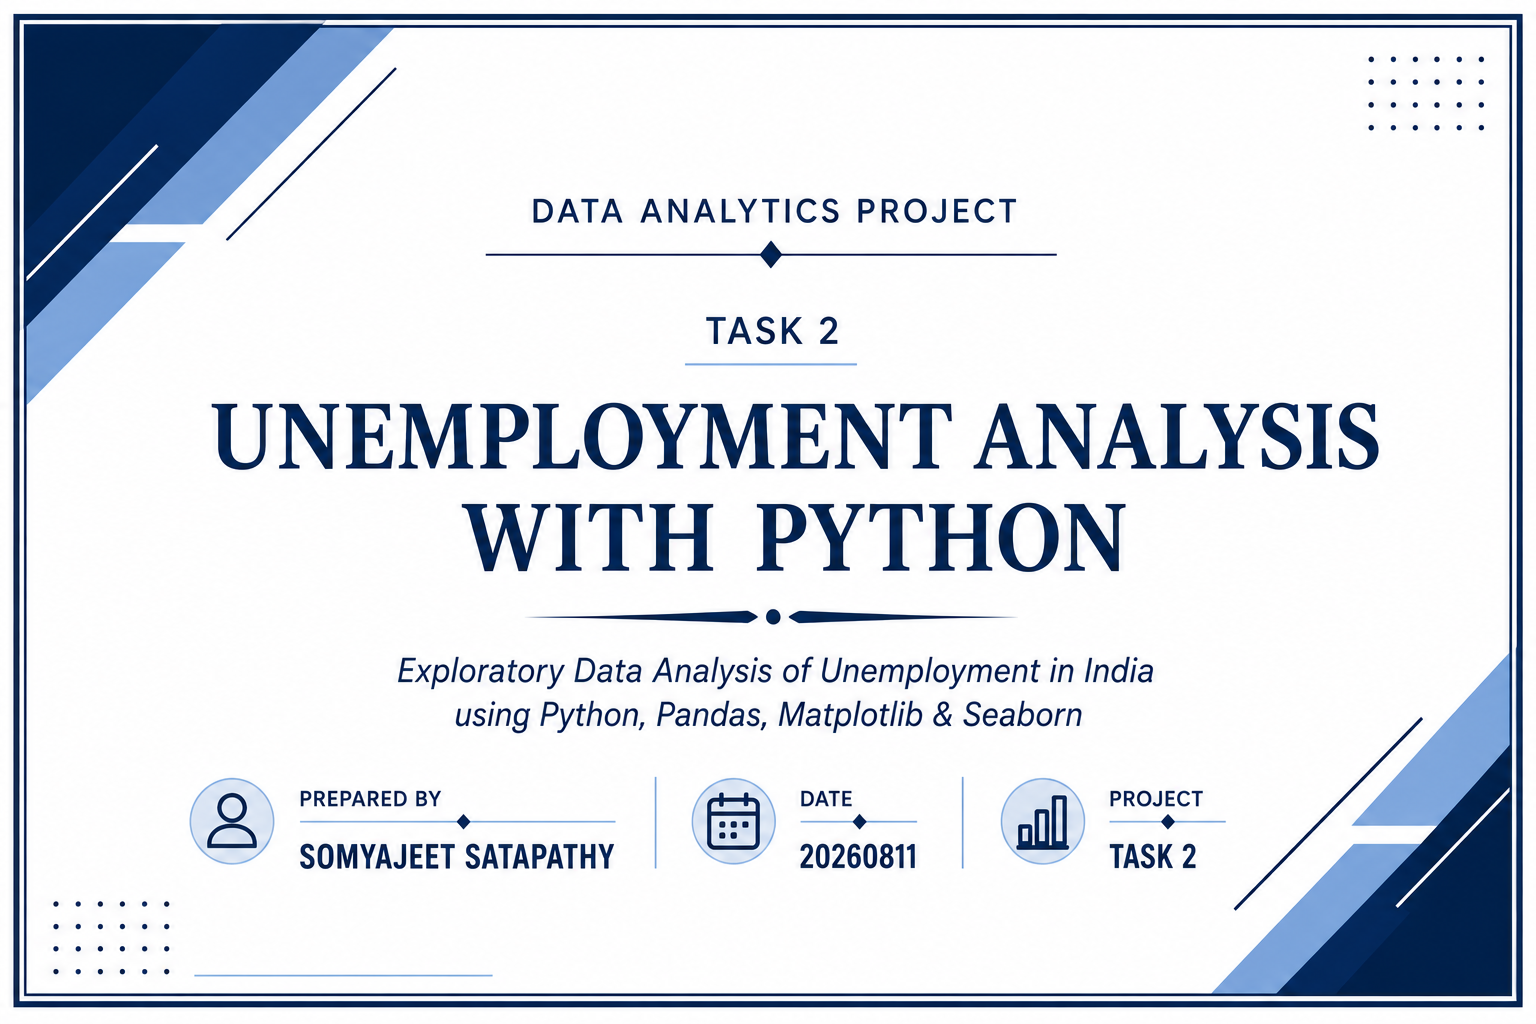

# Unemployment Analysis with Python

### **Oasis Infobyte Data Science Internship**

> ### **By Somyajeet Satapathy**

> ### **Data Science**

> ### **Task 2 — Unemployment Analysis with Python**

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
unemployment_data = pd.read_csv('/content/Unemployment in India.csv')
unemployment_data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [61]:
# Quick check of the dataset before starting the analysis
unemployment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [62]:
# Checking whether any column has missing values
unemployment_data.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [63]:
# Checking for repeated records
unemployment_data.duplicated().sum()

np.int64(27)

In [64]:
# Cleaning the extra spaces from the column names
unemployment_data.columns = unemployment_data.columns.str.strip()

print(unemployment_data.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [65]:
# Converting the date column into datetime format for monthly analysis
unemployment_data['Date'] = pd.to_datetime(unemployment_data['Date'], dayfirst=True)

unemployment_data['Date'].head()

,Date
0,2019-05-31
1,2019-06-30
2,2019-07-31
3,2019-08-31
4,2019-09-30


In [66]:
# Checking the final structure and data types
unemployment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB


In [67]:
# Checking missing values in each column
unemployment_data.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [68]:
# Checking the number of rows and columns
print("Rows:", unemployment_data.shape[0])
print("Columns:", unemployment_data.shape[1])

Rows: 768
Columns: 7


In [69]:
# Getting a quick statistical summary of the numerical columns
unemployment_data.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [70]:
# Removing rows where all columns are empty
unemployment_data = unemployment_data.dropna(how='all').reset_index(drop=True)

print("Rows after removing empty rows:", unemployment_data.shape[0])

Rows after removing empty rows: 740


In [71]:
# Checking that no missing values remain in the cleaned dataset
print(unemployment_data.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [72]:
# Finding the average unemployment rate for each region
region_average = unemployment_data.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

region_average

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


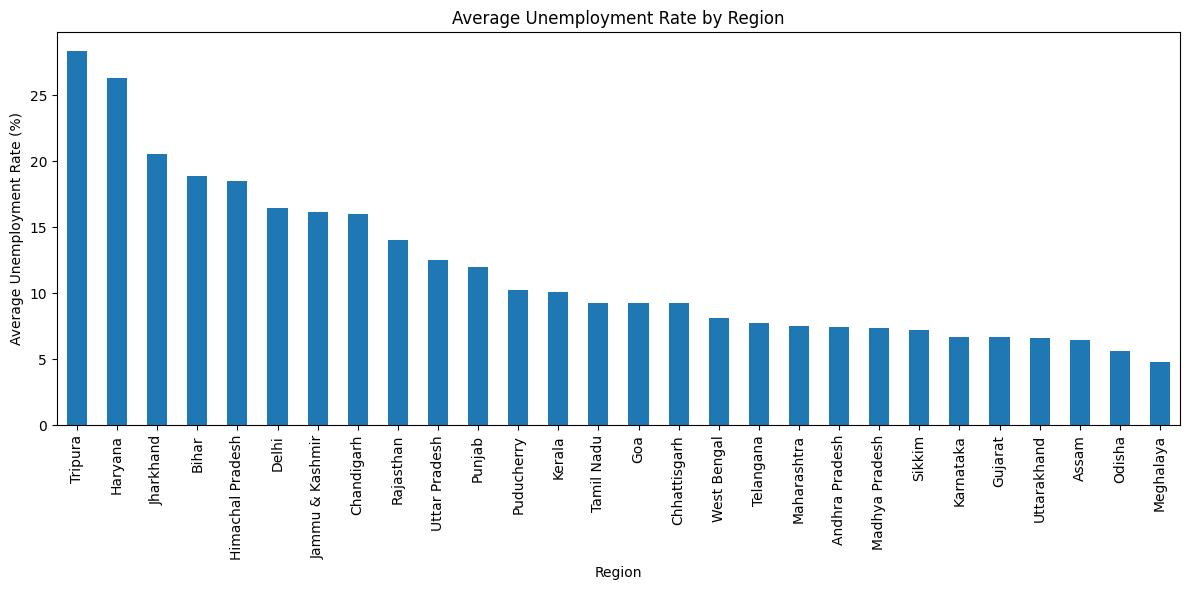

In [73]:
# Comparing the average unemployment rate across regions
plt.figure(figsize=(12,6))
region_average.plot(kind='bar')
plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation

The average unemployment rate varies across the regions. Some regions have noticeably higher unemployment levels than others, showing that unemployment was not evenly distributed across the country during the period covered by the dataset.

In [74]:
# Selecting the 10 regions with the highest average unemployment rate
top_regions = region_average.head(10)

top_regions

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


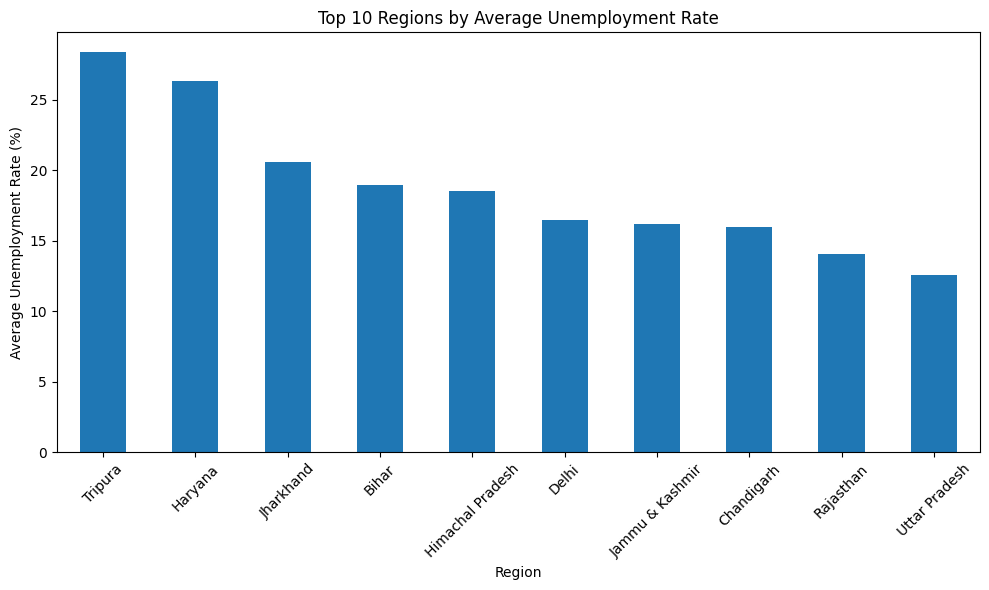

In [75]:
# Comparing the regions with the highest average unemployment rate
plt.figure(figsize=(10,6))
top_regions.plot(kind='bar')
plt.title('Top 10 Regions by Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Tripura has the highest average unemployment rate among the regions in the dataset, followed by Haryana and Jharkhand. The top 10 regions show noticeably higher unemployment levels compared with several other regions.

In [76]:
# Checking the relationship between the main numerical variables
correlation_data = unemployment_data[
    ['Estimated Unemployment Rate (%)',
     'Estimated Employed',
     'Estimated Labour Participation Rate (%)']
]

correlation_data.corr()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


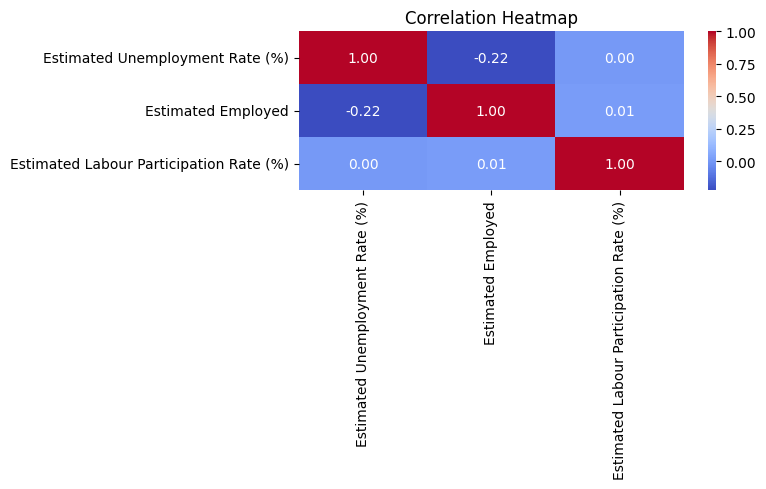

In [77]:
# Visualising the correlations between unemployment, employment and labour participation
plt.figure(figsize=(8,5))
sns.heatmap(correlation_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Observation

The heatmap shows how unemployment rate, estimated employment and labour participation rate are related to each other. The correlation values help identify whether these variables tend to increase or decrease together during the period covered by the dataset.

In [78]:
# Separating the data into pre-COVID and post-COVID periods
pre_covid = unemployment_data[unemployment_data['Date'] < '2020-03-01']
post_covid = unemployment_data[unemployment_data['Date'] >= '2020-03-01']

print("Pre-COVID records:", len(pre_covid))
print("Post-COVID records:", len(post_covid))

Pre-COVID records: 536
Post-COVID records: 204


In [79]:
# Comparing the average unemployment rate before and after the COVID period began
pre_covid_rate = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_covid_rate = post_covid['Estimated Unemployment Rate (%)'].mean()

print("Pre-COVID average unemployment rate:", round(pre_covid_rate, 2), "%")
print("Post-COVID average unemployment rate:", round(post_covid_rate, 2), "%")

Pre-COVID average unemployment rate: 9.51 %
Post-COVID average unemployment rate: 17.77 %


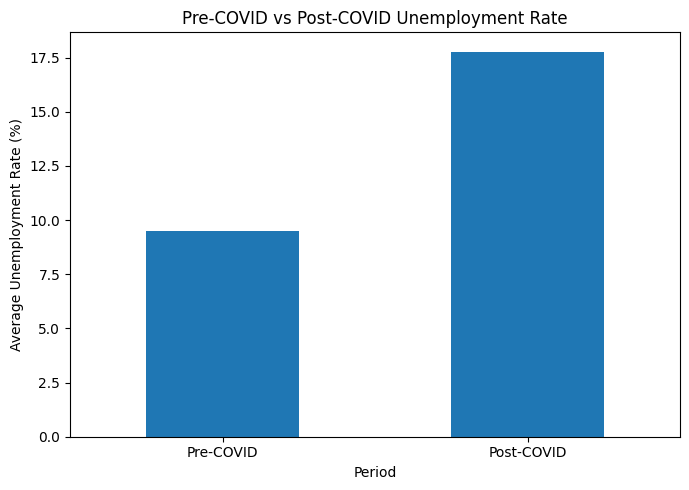

In [80]:
# Visualising the difference between the two periods
period_rates = pd.Series({
    'Pre-COVID': pre_covid_rate,
    'Post-COVID': post_covid_rate
})

plt.figure(figsize=(7,5))
period_rates.plot(kind='bar')
plt.title('Pre-COVID vs Post-COVID Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The comparison shows a clear difference in the average unemployment rate between the pre-COVID and post-COVID periods. This helps identify the change in unemployment conditions during the period affected by the COVID-19 pandemic.

In [81]:
# Selecting three regions to compare their unemployment trends over time
selected_regions = ['Haryana', 'Tripura', 'Jharkhand']

region_trends = unemployment_data[
    unemployment_data['Region'].isin(selected_regions)
].groupby(['Date', 'Region'])['Estimated Unemployment Rate (%)'].mean().unstack()

region_trends

Region,Haryana,Jharkhand,Tripura
Date,,,
2019-05-31,19.605,12.170,31.970
2019-06-30,21.750,14.485,26.115
2019-07-31,20.835,12.825,24.140
2019-08-31,27.565,16.155,29.470
2019-09-30,21.600,14.140,31.900
2019-10-31,22.605,12.810,27.105
2019-11-30,21.825,12.705,26.200
2019-12-31,26.605,18.580,30.005
2020-01-31,21.725,14.560,33.140


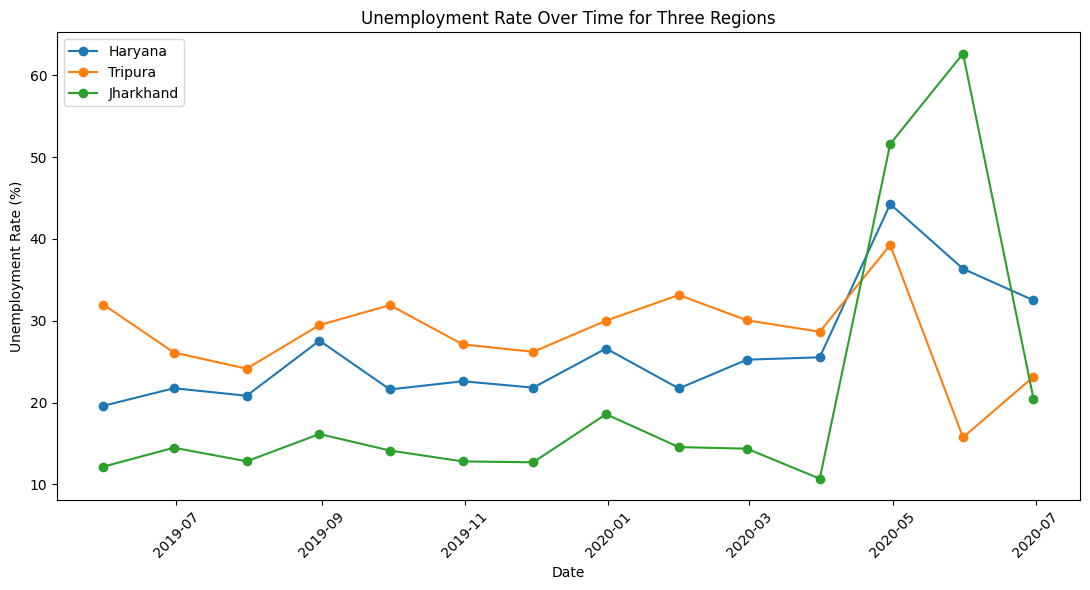

In [82]:
# Comparing unemployment trends for three selected regions
plt.figure(figsize=(11,6))

for region in selected_regions:
    plt.plot(region_trends.index, region_trends[region], marker='o', label=region)

plt.title('Unemployment Rate Over Time for Three Regions')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The unemployment rates of the three selected regions changed noticeably over time. The trends are not identical across the regions, showing that the impact of changing economic conditions was different from one region to another.

In [83]:
# Saving the cleaned dataset for future reference
unemployment_data.to_csv('Cleaned_Unemployment_Data.csv', index=False)

## Key Findings

- Tripura recorded the highest average unemployment rate at about 28.35%, followed by Haryana at 26.28% and Jharkhand at 20.59%.
- Odisha recorded one of the lower average unemployment rates in the dataset, at about 5.66%.
- The monthly analysis showed that unemployment rates changed considerably over the study period.
- The three-region time-series comparison showed that unemployment trends varied between regions over time.
- The correlation analysis showed the relationship between unemployment, estimated employment and labour participation.
- The pre-COVID and post-COVID comparison showed a noticeable change in the average unemployment rate during the COVID-19 period.

## Conclusion

This analysis explored unemployment patterns across different regions and time periods in India using Python. The results showed considerable differences in average unemployment rates between regions, with Tripura having the highest average rate among the regions analysed.

The monthly and regional time-series analysis also showed that unemployment changed over time and that different regions experienced different trends. The pre-COVID and post-COVID comparison highlighted a noticeable change in unemployment conditions during the pandemic period.

Overall, the analysis demonstrates how Python, Pandas, Matplotlib and Seaborn can be used to clean, analyse and visualise unemployment data to identify meaningful regional and temporal patterns.